In [5]:
#import libraries
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
from astropy.convolution import convolve, Gaussian2DKernel, Tophat2DKernel
from astropy.modeling.models import Gaussian2D
from reproject import reproject_interp
import matplotlib.pyplot as plt
import Galaxy_info as gi
#exception handeling
import warnings
warnings.simplefilter('ignore')

ModuleNotFoundError: No module named 'reproject'

In [3]:
def reproject_image(target_fits, object_fits, target_arcsec_per_pix, oblect_arcsec_per_pix, target_fwhm = 6, object_fwhm = 1.2):

    #initialize target header
    target_header = target_fits[0].header

    #initialize target wcs
    target_wcs = WCS(target_header)

    #initialize object header
    object_header = object_fits[0].header

    #initialize object wcs
    object_wcs = WCS(object_header)

    #iterate wcs
    for index in range(0, target_wcs.naxis if target_wcs.naxis >= object_wcs.naxis else object_wcs.naxis):
        #print(target_wcs.naxis, object_wcs.naxis)

        #check wcs size
        if target_wcs.naxis > object_wcs.naxis:

            #reduce wcs size
            target_wcs = target_wcs.dropaxis(2)

        #check wcs size
        elif object_wcs.naxis > target_wcs.naxis:

            #reduce wcs size
            object_wcs = object_wcs.dropaxis(2)
        else:
            continue

    #print(target_wcs.naxis)
    
    #reproject object with target parameters
    object_reprojected, footprint = reproject_interp(object_fits, target_wcs)

    #calculate sigmas
    object_sig = object_fwhm/(2* (np.sqrt(2*np.log(2))))/target_arcsec_per_pix
    target_sig = target_fwhm/(2* (np.sqrt(2*np.log(2))))/target_arcsec_per_pix

    #generate kernal
    ker = np.sqrt((target_sig**2)-(object_sig**2))
    
    #calculate gaussian
    gauss_kernel = Gaussian2DKernel(ker)

    #smooth object image
    smoothed_data_gauss = convolve(object_reprojected, gauss_kernel)

    return smoothed_data_gauss

In [3]:
# #initialize target fits file path
# target_path = '/Users/tylerdonahue/Documents/School/UCs/UCSD/STARTastro/Dwarf Galaxy ISM Project/Data/STARTAstro_dwarf_shells/data/ddo50_hi.fits'
    
# #initilize object fits file path
# object_path = "/Users/tylerdonahue/Documents/School/UCs/UCSD/STARTastro/Dwarf Galaxy ISM Project/Data/STARTAstro_dwarf_shells/data/ddo50_ha.fits"

# #load target fits file
# target_hdu = fits.open(target_path)
    
# #load object fits file
# object_hdu = fits.open(object_path)

# #fwhm hi
# target_fwhm = 6

# #fwhm ha
# object_fwhm = 1.2

# #arc pix hi
# target_arc_per_pix = 4.166666768E-04 * 3600

# #arc pix ha
# object_arc_per_pix = 8.4722204e-05 * 3600

# #reproject object
# repo = reproject_image(target_hdu, object_hdu, target_arc_per_pix, object_arc_per_pix)

# #plot repo
# plt.imshow(repo, origin="lower", cmap="magma")
# plt.show()

In [4]:
#fits.writeto("test.fits", repo, target_hdu[0].header, overwrite=True)

In [2]:
# for galaxy in gi.Galaxy_Info:

#     #load in galaxy
#     file = gi.Galaxy_Info[galaxy]

#     #load image paths
#     target_path = file[1]
#     object_path = file[2]
    
#     #load target fits file
#     target_hdu = fits.open(target_path)
    
#     #load object fits file
#     object_hdu = fits.open(object_path)

#     #reproject object
#     repo = reproject_image(target_hdu, object_hdu, target_arc_per_pix, object_arc_per_pix)

#     #write to fits file
#     fits.writeto(f"{galaxy}_ha.fits", repo, target_hdu[0].header, overwrite=True)

In [1]:
# for galaxy in gi.Galaxy_Info:

#     #load in galaxy
#     file = gi.Galaxy_Info[galaxy]

#     #load image paths
#     target_path = file[1]
#     object_path = file[4]
    
#     #load target fits file
#     target_hdu = fits.open(target_path)
    
#     #load object fits file
#     object_hdu = fits.open(object_path)

#     #arc pix hi
#     target_arc_per_pix = 4.166666768E-04 * 3600

#     #read in irac pixel to arcsec conversion
#     cdelt = "CD2_2" if "CD2_2" in object_hdu[0].header else "CDELT2"
#     object_arc_per_pix = np.abs(object_hdu[0].header[cdelt]) * 3600

#     #irac fwhm
#     fwhm = 1.2

#     #reproject object
#     repo = reproject_image(target_hdu, object_hdu, target_arc_per_pix, object_arc_per_pix, object_fwhm=fwhm)

#     #write to fits file
#     fits.writeto(f"{galaxy}_irac.fits", repo, target_hdu[0].header, overwrite=True)

In [14]:
##TEST##

# Open the FITS file in update mode
hdulist = fits.open("..//Data/STARTAstro_dwarf_shells/test-data/WLM_test_hi.FITS", mode='update')
# Access the primary HDU (usually index 0)
hdu = hdulist[0]

hdu.data[:] = 1000.0

print(hdu.data)

hdulist.close()

# Open the FITS file in update mode
hdulist = fits.open("..//Data/STARTAstro_dwarf_shells/test-data/WLM_test_ha.fits", mode='update')
# Access the primary HDU (usually index 0)
hdu = hdulist[0]

hdu.data[:] = 1000.0

print(hdu.data)
hdulist.close()

[[[[1000. 1000. 1000. ... 1000. 1000. 1000.]
   [1000. 1000. 1000. ... 1000. 1000. 1000.]
   [1000. 1000. 1000. ... 1000. 1000. 1000.]
   ...
   [1000. 1000. 1000. ... 1000. 1000. 1000.]
   [1000. 1000. 1000. ... 1000. 1000. 1000.]
   [1000. 1000. 1000. ... 1000. 1000. 1000.]]]]
[[1000. 1000. 1000. ... 1000. 1000. 1000.]
 [1000. 1000. 1000. ... 1000. 1000. 1000.]
 [1000. 1000. 1000. ... 1000. 1000. 1000.]
 ...
 [1000. 1000. 1000. ... 1000. 1000. 1000.]
 [1000. 1000. 1000. ... 1000. 1000. 1000.]
 [1000. 1000. 1000. ... 1000. 1000. 1000.]]


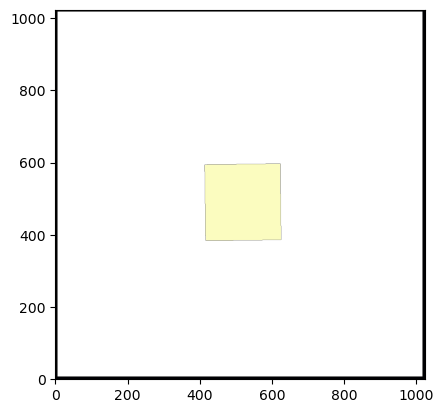

In [15]:
##TEST#####

test_target = "..//Data/STARTAstro_dwarf_shells/test-data/WLM_test_hi.FITS"
test_object = "..//Data/STARTAstro_dwarf_shells/test-data/WLM_test_ha.fits"

test_target_hdu = fits.open(test_target)
test_object_hdu = fits.open(test_object)

#arc pix hi
test_target_arc_per_pix = 4.166666768E-04 * 3600

#arc pix ha
test_object_arc_per_pix = 8.4722204e-05 * 3600

repo_test = reproject_image(test_target_hdu, test_object_hdu, test_target_arc_per_pix, test_object_arc_per_pix)

#plot repo
plt.imshow(repo_test, origin="lower", cmap="magma")
plt.show()

In [16]:
print(repo_test)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
